In [44]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("D:/Python/Projeto Ibovespa/data/all_ibovespa.csv")
df

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios
0,2023-01-02,NEOE3,NEOENERGIA,15.40,15.40,14.98,15.03,325000.0,4.902151e+08
1,2023-01-02,NEXP3,NEXPE,0.31,0.31,0.29,0.30,197700.0,5.898000e+06
2,2023-01-02,NGRD3,NEOGRID,1.48,1.50,1.43,1.45,589900.0,8.615090e+07
3,2023-01-02,NINJ3,GETNINJAS,2.70,2.79,2.69,2.71,76000.0,2.079260e+07
4,2023-01-02,NORD3,NORDON MET,8.48,9.00,8.48,8.50,2700.0,2.314300e+06
...,...,...,...,...,...,...,...,...,...
273571,2026-03-16,JSLG3,JSL,6.40,6.73,6.40,6.63,1415400.0,9.330988e+08
273572,2026-03-16,KEPL3,KEPLER WEBER,7.80,7.92,7.68,7.74,2542000.0,1.974105e+09
273573,2026-03-16,BIED3,BIOMA EDUC,7.00,7.06,6.83,6.89,7600.0,5.273400e+06
273574,2026-03-16,BIOM3,BIOMM,7.15,7.60,7.06,7.50,83800.0,6.200590e+07


In [10]:
df_itau = df[df['sigla_acao'] == 'ITUB4']
df_itau

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios
218,2023-01-02,ITUB4,ITAUUNIBANCO,24.43,24.53,24.04,24.49,23340700.0,5.664208e+10
502,2023-01-03,ITUB4,ITAUUNIBANCO,24.49,24.65,23.83,23.98,29873800.0,7.189867e+10
859,2023-01-04,ITUB4,ITAUUNIBANCO,24.06,24.52,23.88,24.05,29881500.0,7.192848e+10
1291,2023-01-05,ITUB4,ITAUUNIBANCO,24.10,24.91,24.02,24.80,36322800.0,8.947754e+10
1656,2023-01-06,ITUB4,ITAUUNIBANCO,24.93,25.31,24.80,25.23,37628200.0,9.429226e+10
...,...,...,...,...,...,...,...,...,...
272174,2026-03-10,ITUB4,ITAUUNIBANCO,43.58,44.20,42.82,43.80,50383100.0,2.202763e+11
272289,2026-03-11,ITUB4,ITAUUNIBANCO,43.27,44.44,43.20,43.89,18482600.0,8.106498e+10
272605,2026-03-12,ITUB4,ITAUUNIBANCO,43.09,43.22,42.30,42.69,27095200.0,1.155164e+11
273140,2026-03-13,ITUB4,ITAUUNIBANCO,42.83,43.35,42.33,42.40,24894900.0,1.062875e+11


In [12]:
df_itau['data_pregao'] = pd.to_datetime(df_itau['data_pregao'], format='%Y-%m-%d')

In [18]:
df_itau['mm5d'] = df_itau['preco_fechamento'].rolling(5).mean()
df_itau['mm21d'] = df_itau['preco_fechamento'].rolling(21).mean()

In [19]:
df_itau.head(10)

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios,mm5d,mm21d
218,2023-01-02,ITUB4,ITAUUNIBANCO,24.43,24.53,24.04,24.49,23340700.0,5.664208e+10,NaN,NaN
502,2023-01-03,ITUB4,ITAUUNIBANCO,24.49,24.65,23.83,23.98,29873800.0,7.189867e+10,NaN,NaN
859,2023-01-04,ITUB4,ITAUUNIBANCO,24.06,24.52,23.88,24.05,29881500.0,7.192848e+10,NaN,NaN
1291,2023-01-05,ITUB4,ITAUUNIBANCO,24.10,24.91,24.02,24.80,36322800.0,8.947754e+10,NaN,NaN
1656,2023-01-06,ITUB4,ITAUUNIBANCO,24.93,25.31,24.80,25.23,37628200.0,9.429226e+10,24.510,NaN
1995,2023-01-09,ITUB4,ITAUUNIBANCO,25.00,25.66,24.89,25.41,25669400.0,6.508859e+10,24.694,NaN
2293,2023-01-10,ITUB4,ITAUUNIBANCO,25.13,26.00,24.92,25.90,31389400.0,8.082919e+10,25.078,NaN
2728,2023-01-11,ITUB4,ITAUUNIBANCO,25.88,26.48,25.76,26.35,34195600.0,8.958595e+10,25.538,NaN
3208,2023-01-12,ITUB4,ITAUUNIBANCO,25.50,26.31,25.40,25.98,51025400.0,1.325175e+11,25.774,NaN
3457,2023-01-13,ITUB4,ITAUUNIBANCO,25.61,25.89,25.14,25.85,20763800.0,5.333849e+10,25.898,NaN


In [21]:
df_itau['preco_fechamento'] = df_itau['preco_fechamento'].shift(-1)
df_itau.head(10)

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios,mm5d,mm21d
218,2023-01-02,ITUB4,ITAUUNIBANCO,24.43,24.53,24.04,24.05,23340700.0,5.664208e+10,NaN,NaN
502,2023-01-03,ITUB4,ITAUUNIBANCO,24.49,24.65,23.83,24.80,29873800.0,7.189867e+10,NaN,NaN
859,2023-01-04,ITUB4,ITAUUNIBANCO,24.06,24.52,23.88,25.23,29881500.0,7.192848e+10,NaN,NaN
1291,2023-01-05,ITUB4,ITAUUNIBANCO,24.10,24.91,24.02,25.41,36322800.0,8.947754e+10,NaN,NaN
1656,2023-01-06,ITUB4,ITAUUNIBANCO,24.93,25.31,24.80,25.90,37628200.0,9.429226e+10,24.510,NaN
1995,2023-01-09,ITUB4,ITAUUNIBANCO,25.00,25.66,24.89,26.35,25669400.0,6.508859e+10,24.694,NaN
2293,2023-01-10,ITUB4,ITAUUNIBANCO,25.13,26.00,24.92,25.98,31389400.0,8.082919e+10,25.078,NaN
2728,2023-01-11,ITUB4,ITAUUNIBANCO,25.88,26.48,25.76,25.85,34195600.0,8.958595e+10,25.538,NaN
3208,2023-01-12,ITUB4,ITAUUNIBANCO,25.50,26.31,25.40,25.57,51025400.0,1.325175e+11,25.774,NaN
3457,2023-01-13,ITUB4,ITAUUNIBANCO,25.61,25.89,25.14,26.10,20763800.0,5.333849e+10,25.898,NaN


In [22]:
df_itau.dropna(inplace=True)
df_itau

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios,mm5d,mm21d
7137,2023-01-30,ITUB4,ITAUUNIBANCO,24.99,25.06,24.53,24.98,35228000.0,8.715086e+10,25.298,25.463810
7583,2023-01-31,ITUB4,ITAUUNIBANCO,25.11,25.59,25.09,25.21,29062700.0,7.385956e+10,25.258,25.503810
8088,2023-02-01,ITUB4,ITAUUNIBANCO,25.19,25.50,24.78,25.12,28111400.0,7.033108e+10,25.130,25.551429
8186,2023-02-02,ITUB4,ITAUUNIBANCO,24.80,25.97,24.70,25.13,46319700.0,1.173008e+11,25.078,25.606667
8753,2023-02-03,ITUB4,ITAUUNIBANCO,24.90,25.36,24.83,24.55,36659600.0,9.220664e+10,25.116,25.621905
...,...,...,...,...,...,...,...,...,...,...,...
271357,2026-03-06,ITUB4,ITAUUNIBANCO,43.46,43.59,42.65,43.80,26063600.0,1.120551e+11,44.350,46.875238
271868,2026-03-09,ITUB4,ITAUUNIBANCO,42.52,43.28,42.35,43.89,40970400.0,1.757031e+11,43.798,46.805714
272174,2026-03-10,ITUB4,ITAUUNIBANCO,43.58,44.20,42.82,42.69,50383100.0,2.202763e+11,43.682,46.723810
272289,2026-03-11,ITUB4,ITAUUNIBANCO,43.27,44.44,43.20,42.40,18482600.0,8.106498e+10,43.458,46.587619


In [33]:
qtd_linhas=len(df_itau)
qtd_linhas_treino = qtd_linhas - 177
qtd_linhas_teste = qtd_linhas - 77

qtd_linhas_validacao = qtd_linhas_treino - qtd_linhas_teste
info = (
    f"Linhas treino = 0:{qtd_linhas_treino}"
    f" Linhas teste = {qtd_linhas_treino}:{qtd_linhas_teste}"
    f" Linhas validacao = {qtd_linhas_teste}:{qtd_linhas}"
)
info

'Linhas treino = 0:600 Linhas teste = 600:700 Linhas validacao = 700:777'

In [34]:
df_itau = df_itau.reset_index(drop=True)
df_itau

,data_pregao,sigla_acao,nome_acao,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,qtd_negocios,volume_negocios,mm5d,mm21d
0,2023-01-30,ITUB4,ITAUUNIBANCO,24.99,25.06,24.53,24.98,35228000.0,8.715086e+10,25.298,25.463810
1,2023-01-31,ITUB4,ITAUUNIBANCO,25.11,25.59,25.09,25.21,29062700.0,7.385956e+10,25.258,25.503810
2,2023-02-01,ITUB4,ITAUUNIBANCO,25.19,25.50,24.78,25.12,28111400.0,7.033108e+10,25.130,25.551429
3,2023-02-02,ITUB4,ITAUUNIBANCO,24.80,25.97,24.70,25.13,46319700.0,1.173008e+11,25.078,25.606667
4,2023-02-03,ITUB4,ITAUUNIBANCO,24.90,25.36,24.83,24.55,36659600.0,9.220664e+10,25.116,25.621905
...,...,...,...,...,...,...,...,...,...,...,...
772,2026-03-06,ITUB4,ITAUUNIBANCO,43.46,43.59,42.65,43.80,26063600.0,1.120551e+11,44.350,46.875238
773,2026-03-09,ITUB4,ITAUUNIBANCO,42.52,43.28,42.35,43.89,40970400.0,1.757031e+11,43.798,46.805714
774,2026-03-10,ITUB4,ITAUUNIBANCO,43.58,44.20,42.82,42.69,50383100.0,2.202763e+11,43.682,46.723810
775,2026-03-11,ITUB4,ITAUUNIBANCO,43.27,44.44,43.20,42.40,18482600.0,8.106498e+10,43.458,46.587619


In [37]:
features = df_itau.drop(['sigla_acao', 'nome_acao', 'data_pregao', 'preco_fechamento'], axis=1)
labels = df_itau['preco_fechamento']

In [38]:
features_list = ('preco_abertura', 'qtd_total_negociado', 'volume_total_negociado', 'mm5d', 'mm21d')

k_best_features = SelectKBest(k='all')
k_best_features.fit_transform(features, labels)
k_best_features_scores = k_best_features.scores_
raw_pairs = zip(features_list[1:], k_best_features_scores)
ordered_pairs = list(reversed(sorted(raw_pairs, key=lambda x: x[1])))

k_best_features_final = dict(ordered_pairs[:15])
best_features = k_best_features_final.keys()
print('')
print("Melhores features")
print(k_best_features_final)


Melhores features
{'qtd_total_negociado': np.float64(21.06360312751133), 'mm5d': np.float64(20.944660336518197), 'volume_total_negociado': np.float64(20.619320750016144), 'mm21d': np.float64(1.3969490139868461)}


In [ ]:
features = df_itau.drop(['sigla_acao', 'nome_acao', 'data_pregao', 'preco_fechamento', 'preco_abertura'], axis=1)

In [45]:
scaler = MinMaxScaler().fit(features)
features_scale = scaler.transform(features)

print('Features', features_scale.shape)
print(features_scale)

Features (777, 7)
[[0.07068366 0.06247619 0.06921887 ... 0.25129743 0.07296344 0.06535761]
 [0.07531866 0.08266667 0.09087394 ... 0.19877625 0.07135985 0.06707218]
 [0.07840865 0.0792381  0.07888631 ... 0.18483331 0.06622835 0.06911332]
 ...
 [0.78872151 0.79161905 0.77648879 ... 0.77734862 0.80997434 0.97664925]
 [0.77674778 0.8007619  0.79118329 ... 0.2272488  0.80099423 0.97081156]
 [0.76979529 0.75428571 0.75638051 ... 0.36338511 0.7944195  0.9593403 ]]


In [46]:
X_train = features_scale[:qtd_linhas_treino]
X_test = features_scale[qtd_linhas_treino:qtd_linhas_teste]

y_train = labels[:qtd_linhas_treino]
y_test = labels[qtd_linhas_treino:qtd_linhas_teste]

print(len(X_train), len(y_train))
print( len(X_test), len(y_test))

600 600
100 100


In [51]:
#treinamento usando regressão linear
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
cd = r2_score(y_test, pred)

f'Coeficente de determinação: {cd *100:.2f}'

'Coeficente de determinação: 69.43'

In [ ]:
rn = MLPRegressor(max_iter=2000, random_state=42)

rn.fit(X_train, y_train)
pred = rn.predict(X_test)

cd = rn.score(X_test, y_test)

f'Coeficiente de determinação:{cd * 100:.2f}'

'Coeficiente de determinação:70.08'

In [67]:
#rede neural com ajuste hyper parameters

rn = MLPRegressor()
parameter_space = {
    'hidden_layer_sizes': [(i,)for i in list(range(1, 21))],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam', 'lbfgs'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
}

search = GridSearchCV(rn, parameter_space, n_jobs=-1, cv=5)

search.fit(X_train, y_train)
clf = search.best_estimator_
pred=search.score(X_test, y_test)

cd = search.score(X_test, y_test)

f'Coeficiente de determinação: {cd * 100:.2f}'

c:\Users\Rael\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


'Coeficiente de determinação: 74.84'

In [68]:
#executando a previsão

previsao=features_scale[qtd_linhas_teste:qtd_linhas]

data_pregao_full= df_itau['data_pregao']
data_pregao = data_pregao_full[qtd_linhas_teste:qtd_linhas]

res_full = df_itau['preco_fechamento']
res = res_full [qtd_linhas_teste:qtd_linhas]

pred = lr.predict(previsao)

df = pd.DataFrame({'data_pregao': data_pregao, 'real':res, 'previsao':pred})
df ['real'] = df['real'].shift(+1)

df.set_index('data_pregao', inplace=True)

print(df)

              real   previsao
data_pregao                  
2025-11-17     NaN  39.916608
2025-11-18   39.85  40.283198
2025-11-19   39.97  39.997920
2025-11-21   39.82  40.028220
2025-11-24   39.91  39.921591
...            ...        ...
2026-03-06   43.16  44.170397
2026-03-09   43.80  43.955254
2026-03-10   43.89  43.210742
2026-03-11   42.69  44.005790
2026-03-12   42.40  43.342722

[77 rows x 2 columns]


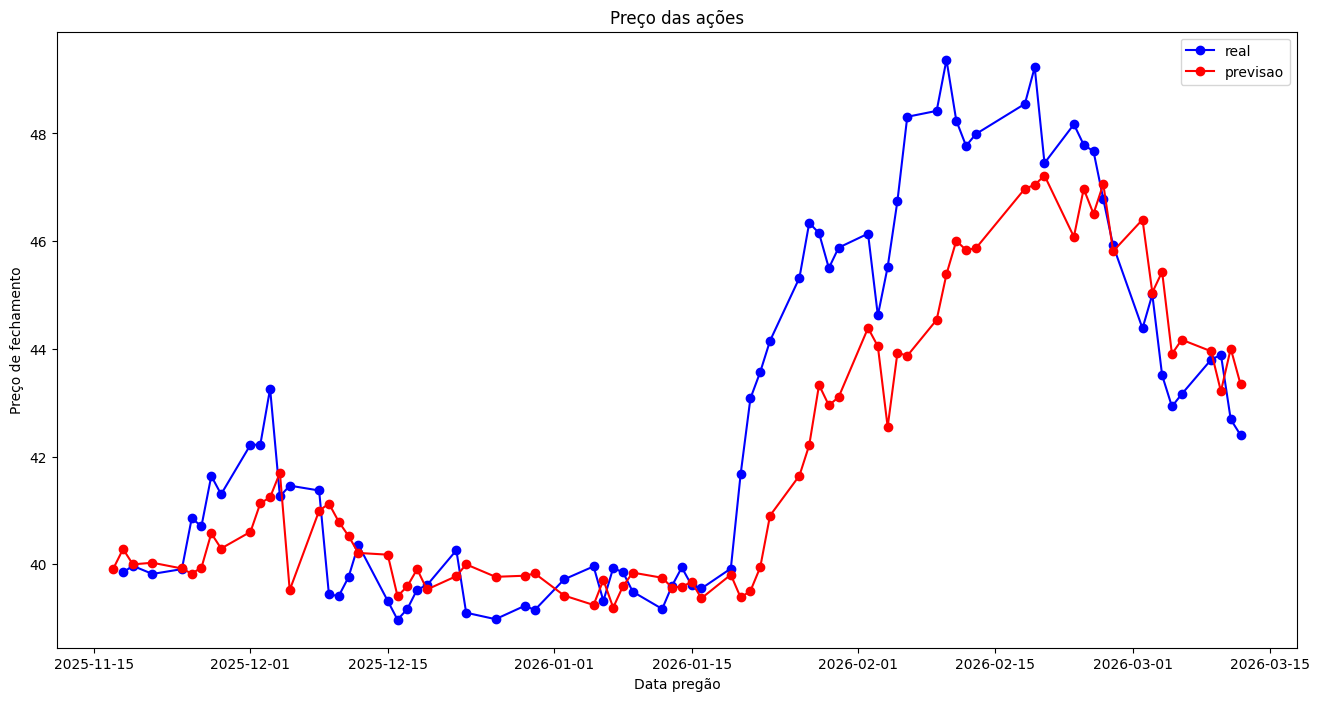

In [69]:
#grafico
plt.figure(figsize=(16,8))
plt.title('Preço das ações')
plt.plot(df['real'], label = "real", color='blue', marker='o')
plt.plot(df['previsao'], label="previsao", color='red', marker='o')
plt.xlabel('Data pregão')
plt.ylabel('Preço de fechamento')
leg = plt.legend()